# 🏕️ 2026 하계 방학 결초보은 AI·데이터분석 교육
> **기간**: 2026.06.29 ~ 2026.07.03 | **대상**: 신입·재학생

이 노트북은 교육 3일차 실습 코드를 담고 있습니다.  
**Day 1** 파이썬 기초 → **Day 2** 데이터 수집·전처리·모델링 → **Day 3** 배포

---


## 📘 Day 1 — 파이썬 기본 문법
> 지금 외울 필요 없어요! 이런 게 있구나 정도만 — 앞으로 진행하면서 "어, 이거 봤던 거다" 하는 순간이 오면 됩니다.


### 1-1. 출력하기 `print()`
`print()` 함수는 화면에 텍스트·숫자를 출력해요. 파이썬에서 제일 먼저 만나는 친구!

In [1]:
print("안녕하세요!")
print("파이썬을 배워봅시다.")

안녕하세요!
파이썬을 배워봅시다.


### 1-2. 변수
데이터를 저장하는 **이름이 붙은 상자**예요. `name = "홍길동"` 은 name 상자에 홍길동을 넣는다는 뜻.

In [2]:
name = "홍길동"
age  = 20

print(name) 
print(age)

홍길동
20


### 1-3. 계산하기
`+  -  *  /` 기호로 사칙연산을 바로 처리해요.

In [3]:
a = 10
b = 5

print(a + b)   # 더하기 → 15
print(a - b)   # 빼기  → 5
print(a * b)   # 곱하기 → 50
print(a / b)   # 나누기 → 2.0

15
5
50
2.0


### 1-4. 조건문 `if / else`
조건에 따라 다른 코드를 실행해요.

In [4]:
score = 85

if score >= 80:
    print("합격")
else:
    print("불합격")

합격


### 1-5. 반복문 `for`
같은 작업을 여러 번 반복해요. `range(5)` = 0부터 4까지 5번.

In [5]:
for i in range(5):
    print(i)

0
1
2
3
4


### 1-6. 리스트
여러 데이터를 순서대로 저장하는 서랍이에요. 인덱스는 0부터 시작!

In [6]:
fruits = ["사과", "바나나", "포도"]

print(fruits[0])  # 첫 번째 → 사과
print(fruits[1])  # 두 번째 → 바나나

사과
바나나


### 1-7. 함수 `def`
자주 쓰는 코드를 이름 붙여 묶어두기. 이름을 부르면 실행돼요.

In [7]:
def hello():
    print("안녕하세요")

hello()  # 함수 호출

안녕하세요


### 1-8. 입력 받기 `input()`
사용자로부터 값을 직접 입력받아요. 챗봇의 기초!

In [9]:
name = input("이름을 입력하세요: ")
print("안녕하세요", name)

안녕하세요 고원욱


---

## 📗 Day 2 — 데이터 수집 · 전처리 · 모델링


### 2-1. 데이터 수집 예시 — DART API (참고용)
> 공공 API를 통해 데이터를 가져오는 방법 예시입니다.
> 참고 자료: https://www.data.go.kr/data/15159617/fileData.do

In [3]:
import requests

# ── DART API 요청 설정 ──────────────────────────────────────
url = "https://opendart.fss.or.kr/api/list.json"
params = {
    "crtfc_key": "Y71041d4ebf51de7256211a6e49145a999708d300",  # ⚠️ 본인 DART API 키로 교체하세요
    "bgn_de": "20260601",         # 시작일 (YYYYMMDD)
    "end_de": "20260612",         # 종료일 (YYYYMMDD)
    "corp_cls": "Y",              # 법인구분: Y(유가), K(코스닥), N(코넥스), E(기타)
    "page_no": "1",               # 페이지 번호
    "page_count": "10"            # 페이지당 건수
}

# ── API 호출 ─────────────────────────────────────────────────
response = requests.get(url, params=params)

# ── 결과 확인 ────────────────────────────────────────────────
if response.status_code == 200:
    data = response.json()
    if data["status"] == "000":
        print("데이터 조회 성공!")
        for item in data["list"]:
            print(f"회사명: {item['corp_name']}, 보고서명: {item['report_nm']}, 접수일: {item['rcept_dt']}")
    else:
        print(f"API 오류 메시지: {data['message']}")
else:
    print(f"HTTP 요청 실패: {response.status_code}")

API 오류 메시지: 잘못된 인증키입니다.발급받은 인증키(40자리)


In [2]:
import pandas as pd

# API 응답 리스트를 DataFrame으로 변환
df = pd.DataFrame(data["list"])
df

KeyError: 'list'

---
### 2-2. 데이터 수집 — FinanceDataReader (실습 메인)
> 복잡한 크롤링 없이 KOSPI 주가 데이터를 몇 줄로 수집할 수 있어요.

```bash
pip install finance-datareader
```

In [4]:
import FinanceDataReader as fdr
import pandas as pd
import time

# ── Step 1. KOSPI 전체 종목 리스트 ──────────────────────────
kospi_list = fdr.StockListing("KOSPI")
symbols = kospi_list["Code"].tolist()

# ── Step 2. 데이터 수집 ──────────────────────────────────────
all_data = []

# ⚠️ 테스트: 상위 10개만 수집. 전체 수집 시 symbols[:10] → symbols 로 변경
for symbol in symbols[:10]:
    try:
        df = fdr.DataReader(symbol, "2021-06-12")  # 5년치 데이터
        df["Symbol"] = symbol                       # 종목 구분 컬럼 추가
        all_data.append(df)
        print(f"{symbol} 데이터 수집 완료")
        time.sleep(0.3)                             # 서버 부하 방지
    except Exception as e:
        print(f"{symbol} 수집 실패: {e}")

# ── Step 3. 병합 및 저장 ─────────────────────────────────────
if all_data:
    combined_df = pd.concat(all_data)

    # ⚠️ 저장 경로를 본인 환경에 맞게 수정하세요!
    # 예: "data/kospi_5years_combined.csv"
    combined_df.to_csv("kospi_5years_combined.csv", encoding="utf-8-sig")
    print("저장 완료!")

combined_df

005930 데이터 수집 완료
000660 데이터 수집 완료
402340 데이터 수집 완료
009150 데이터 수집 완료
005935 데이터 수집 완료
005380 데이터 수집 완료
373220 데이터 수집 완료
032830 데이터 수집 완료
028260 데이터 수집 완료
207940 데이터 수집 완료
저장 완료!


,Open,High,Low,Close,Volume,Change,Symbol
Date,,,,,,,
2021-06-14,80800,80900,80500,80500,10550078,-0.006173,005930
2021-06-15,80900,81200,80600,80900,10075685,0.004969,005930
2021-06-16,81500,81900,81100,81800,14999855,0.011125,005930
2021-06-17,81100,81300,80700,80900,14007385,-0.011002,005930
2021-06-18,81100,81100,80500,80500,14916721,-0.004944,005930
...,...,...,...,...,...,...,...
2026-06-25,1383000,1428000,1361000,1386000,76241,0.000722,207940
2026-06-26,1401000,1402000,1309000,1343000,53490,-0.031025,207940
2026-06-29,1358000,1456000,1347000,1448000,85788,0.078183,207940


---
### 2-3. 데이터 전처리
> 실제 데이터에는 **결측치(Missing Value)** 와 **이상치(Outlier)** 가 반드시 존재합니다.
> 아래 함수로 교육용 오염 데이터를 직접 만들어보고 처리해봐요.

**오염 유형**
- `missing` : 결측치 주입 (값이 비어있는 상태)
- `outlier` : 이상치 주입 (가격 10배 폭등 시뮬레이션)
- `noise`   : 가우시안 노이즈 추가 (5% 수준)
- `shuffle` : 시계열 순서 파괴

In [5]:
import pandas as pd
import numpy as np

def create_corrupted_data(df, corruption_type="missing", rate=0.1):
    """
    교육용 오염 데이터 생성 함수

    Args:
        df              : 입력 DataFrame
        corruption_type : "missing" | "outlier" | "noise" | "shuffle"
        rate            : 오염 비율 (0.0 ~ 1.0)
    Returns:
        오염된 DataFrame 복사본
    """
    corrupted_df = df.copy()

    if corruption_type == "missing":
        # 결측치 주입
        idx = np.random.choice(corrupted_df.index, size=int(len(corrupted_df) * rate), replace=False)
        corrupted_df.loc[idx, "Close"] = np.nan

    elif corruption_type == "outlier":
        # 이상치 주입 (가격 10배 폭등 시뮬레이션)
        idx = np.random.choice(corrupted_df.index, size=int(len(corrupted_df) * rate), replace=False)
        corrupted_df.loc[idx, "Close"] = corrupted_df.loc[idx, "Close"] * 10

    elif corruption_type == "noise":
        # 가우시안 노이즈 추가 (5% 수준)
        noise = np.random.normal(0, 0.05, len(corrupted_df))
        corrupted_df["Close"] = corrupted_df["Close"] * (1 + noise)

    elif corruption_type == "shuffle":
        # 시계열 순서 파괴 (종목별 가격 데이터 뒤섞기)
        corrupted_df["Close"] = (
            corrupted_df.groupby("Symbol")["Close"]
            .sample(frac=1.0)
            .values
        )

    return corrupted_df


# combined_df는 2-2에서 수집한 데이터입니다
df_missing = create_corrupted_data(combined_df, "missing", rate=0.05)  # 5% 결측치
df_outlier = create_corrupted_data(combined_df, "outlier", rate=0.01)  # 1% 이상치

#### 결측치 확인 및 시각화

In [6]:
# 결측치가 있는 행만 확인
df_missing[df_missing["Close"].isna()]

,Open,High,Low,Close,Volume,Change,Symbol
Date,,,,,,,
2021-06-16,81500,81900,81100,NaN,14999855,0.011125,005930
2021-06-22,80200,80300,79900,NaN,11773365,0.001252,005930
2021-06-23,80500,80600,79900,NaN,13856548,0.001250,005930
2021-06-30,81100,81400,80700,NaN,13288643,-0.003704,005930
2021-07-08,81100,81200,79900,NaN,16660998,-0.011139,005930
...,...,...,...,...,...,...,...
2026-06-19,1442000,1443000,1346000,NaN,99207,-0.039161,207940
2026-06-23,1300000,1344000,1270000,NaN,61840,-0.016988,207940
2026-06-25,1383000,1428000,1361000,NaN,76241,0.000722,207940


/opt/anaconda3/envs/gyelocho1/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/gyelocho1/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/gyelocho1/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/gyelocho1/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/gyelocho1/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51077 (\N{HANGUL 

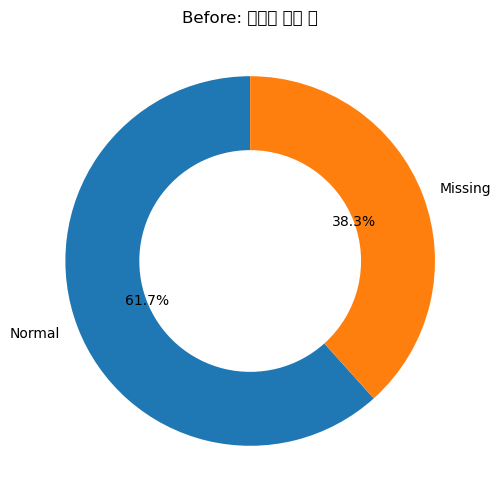

In [7]:
import matplotlib.pyplot as plt

def plot_missing_ratio(df, title="Missing Value Ratio"):
    """결측치 비율 도넛 차트"""
    total   = len(df)
    missing = df["Close"].isna().sum()
    normal  = total - missing

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(
        [normal, missing],
        labels=["Normal", "Missing"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops=dict(width=0.4)  # 도넛 형태
    )
    plt.title(title)
    plt.show()

plot_missing_ratio(df_missing, "Before: 결측치 주입 후")

#### 결측치 처리 — 선형 보간 (Linear Interpolation)
> 앞뒤 값을 이용해 빈 칸을 직선으로 채워요. 주가 같은 시계열 데이터에 적합합니다.

/opt/anaconda3/envs/gyelocho1/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/gyelocho1/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/gyelocho1/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/gyelocho1/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/gyelocho1/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52376 (\N{HANGU

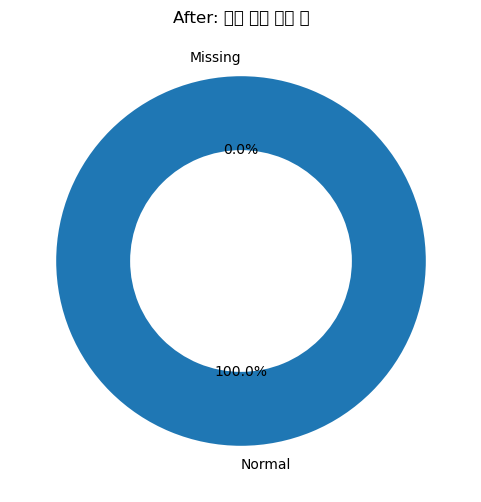

In [8]:
import pandas as pd

def linear_interpolation(df):
    """선형 보간으로 결측치 처리"""
    cleaned_df = df.copy()
    cleaned_df["Close"] = (
        cleaned_df["Close"]
        .interpolate(method="linear")
    )
    return cleaned_df


df_interp = linear_interpolation(df_missing)

# 처리 후 결측치 비율 확인
plot_missing_ratio(df_interp, "After: 선형 보간 처리 후")

#### 이상치 처리 — IQR + Winsorizing
> 사분위수(Q1, Q3)로 정상 범위를 계산하고, 그 밖의 값을 경계값으로 **클리핑**해요.
> 데이터를 삭제하지 않아 손실이 없다는 장점이 있어요.

```
IQR    = Q3 - Q1
하한선 = Q1 - 1.5 × IQR
상한선 = Q3 + 1.5 × IQR
```

In [9]:
def winsorize_iqr(df):
    """IQR 기반 이상치 Winsorizing 처리"""
    cleaned = df.copy()

    Q1  = cleaned["Close"].quantile(0.25)
    Q3  = cleaned["Close"].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR  # 하한선

    upper = Q3 + 1.5 * IQR  # 상한선

    # 경계값으로 클리핑 (삭제하지 않고 경계값으로 대체)
    cleaned["Close"] = cleaned["Close"].clip(lower, upper)

    return cleaned

/var/folders/v8/y347rtrj6kdf2wx2h8snzsnm0000gn/T/ipykernel_9547/3671912314.py:14: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v8/y347rtrj6kdf2wx2h8snzsnm0000gn/T/ipykernel_9547/3671912314.py:14: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v8/y347rtrj6kdf2wx2h8snzsnm0000gn/T/ipykernel_9547/3671912314.py:14: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v8/y347rtrj6kdf2wx2h8snzsnm0000gn/T/ipykernel_9547/3671912314.py:14: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v8/y347rtrj6kdf2wx2h8snzsnm0000gn/T/ipykernel_9547/3671912314.py:14: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/v8/y347rtrj6kdf2wx2h8snzsnm0000gn/T/ipykernel_9547/

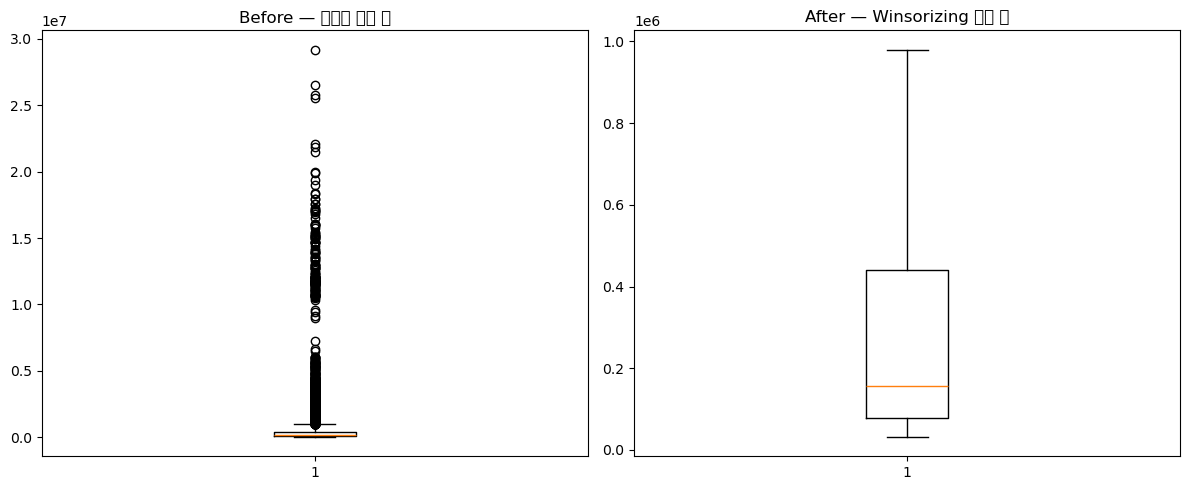

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 처리 전
axes[0].boxplot(df_outlier["Close"].dropna())
axes[0].set_title("Before — 이상치 주입 후")

# 처리 후
cleaned_df = winsorize_iqr(df_outlier)
axes[1].boxplot(cleaned_df["Close"].dropna())
axes[1].set_title("After — Winsorizing 처리 후")

plt.tight_layout()
plt.show()

---
### 2-4. 모델링 — 다음날 종가 예측
> 전처리된 데이터를 모델에 넣어(input) → 다음날 종가(output)를 예측해요.

```bash
pip install scikit-learn xgboost lightgbm
```

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [12]:
df = combined_df.copy()

# ── 정답(Target) 설정: 다음날 종가 ──────────────────────────
df["Target"] = (
    df.groupby("Symbol")["Close"]
      .shift(-1)   # 1행 앞으로 당기기 = 다음날 종가
)
df = df.dropna()  # Target이 없는 마지막 행 제거

# ── 피처 및 타겟 분리 ────────────────────────────────────────
features = ["Open", "High", "Low", "Close", "Volume"]
X = df[features]
y = df["Target"]

# ── 학습/테스트 분리 (시계열이므로 shuffle=False 필수!) ──────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False  # ⚠️ 시계열 데이터는 반드시 False
)

In [13]:
# ── 모델 학습 ────────────────────────────────────────────────

# 1. Linear Regression — 가장 단순, 해석 용이
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# 2. Random Forest — 안정적, 성능 우수
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# 3. XGBoost — 고성능 그래디언트 부스팅
xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

# 4. LightGBM — 빠르고 메모리 효율적
lgbm = LGBMRegressor(n_estimators=100, random_state=42)
lgbm.fit(X_train, y_train)
pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000243 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 9662, number of used features: 5
[LightGBM] [Info] Start training from score 194286.157110


In [14]:
def evaluate(y_true, pred):
    """모델 성능 평가 — MAE / RMSE / R²"""
    mae  = mean_absolute_error(y_true, pred)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    r2   = r2_score(y_true, pred)
    return mae, rmse, r2


# ── 결과 비교표 ───────────────────────────────────────────────
results = pd.DataFrame(columns=["Model", "MAE", "RMSE", "R²"])

for name, pred in {
    "Linear"      : pred_lr,
    "RandomForest": pred_rf,
    "XGBoost"     : pred_xgb,
    "LightGBM"    : pred_lgbm,
}.items():
    mae, rmse, r2 = evaluate(y_test, pred)
    results.loc[len(results)] = [name, round(mae,2), round(rmse,2), round(r2,4)]

print(results.to_string(index=False))

       Model      MAE     RMSE     R²
      Linear 10994.50 19838.04 0.9989
RandomForest 28559.46 51357.50 0.9928
     XGBoost 40152.25 68292.51 0.9873
    LightGBM 32086.63 60322.31 0.9901


In [16]:
import joblib

# ⚠️ 저장 경로를 본인 환경에 맞게 수정하세요!
# 예: "models/lr_model.pkl"
joblib.dump(lr,   "models/lr_model.pkl")
joblib.dump(rf,   "models/rf_model.pkl")
joblib.dump(xgb,  "models/xgb_model.pkl")
joblib.dump(lgbm, "models/lgbm_model.pkl")

print("모델 저장 완료! → models/ 폴더 확인")

모델 저장 완료! → models/ 폴더 확인


---
## 🚀 Day 3 — 배포
> 학습된 모델을 `models/` 폴더에 저장한 뒤, `app.py` 를 실행해서 Streamlit 대시보드를 완성하세요.

```bash
# 로컬 실행
streamlit run app.py

# GitHub 업로드 후 Streamlit Cloud 배포
git add .
git commit -m "Complete stock dashboard"
git push origin main
```

> 자세한 배포 순서는 커리큘럼 문서 또는 교육자료 HTML 파일을 참고하세요!